### Training a simple logistic regression using only the C0 probability outputs for one disease only

In [1]:
# ── Imports ────────────────────────────────────────────────────────

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import joblib  # to save the trained model

In [2]:
# ── Config ─────────────────────────────────────────────────────────

BASE_DIR   = "/zhome/d0/a/221493/thesis"
DATA_DIR   = os.path.join(BASE_DIR, "results/C0_baseline")
OUTPUT_DIR = os.path.join(BASE_DIR, "results/C2_baseline")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
# ── Load the C0 prediction CSVs ────────────────────────────────────

train_df = pd.read_csv(os.path.join(DATA_DIR, "train_c0_effusion.csv"))
valid_df = pd.read_csv(os.path.join(DATA_DIR, "valid_c0_effusion.csv"))

print(f"Train rows: {len(train_df)}")
print(f"Valid rows: {len(valid_df)}")
train_df

Train rows: 503
Valid rows: 200


,path,prob,true,pred,correct,margin
0,CheXpert-v1.0-small/train/patient00001/study1/...,0.641115,0.0,1,0,0.006866
1,CheXpert-v1.0-small/train/patient00002/study2/...,0.681220,1.0,1,1,0.046970
2,CheXpert-v1.0-small/train/patient00004/study1/...,0.570345,0.0,0,1,0.063905
3,CheXpert-v1.0-small/train/patient00005/study1/...,0.579604,0.0,0,1,0.054646
4,CheXpert-v1.0-small/train/patient00006/study1/...,0.556092,0.0,0,1,0.078158
...,...,...,...,...,...,...
498,CheXpert-v1.0-small/train/patient00689/study14...,0.701559,0.0,1,0,0.067309
499,CheXpert-v1.0-small/train/patient00690/study1/...,0.572843,0.0,0,1,0.061407
500,CheXpert-v1.0-small/train/patient00691/study10...,0.706352,1.0,1,1,0.072102
501,CheXpert-v1.0-small/train/patient00692/study1/...,0.632559,0.0,0,1,0.001691


In [5]:
# ── Define features and target ─────────────────────────────────────
#
# Features: what C2 gets to see
#   prob   → C0's raw sigmoid probability
#
# Target: what C2 is trying to predict
#   correct → was C0 right? (1=yes, 0=no)

FEATURES = ["prob"]
TARGET   = "correct"

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values

X_valid = valid_df[FEATURES].values
y_valid = valid_df[TARGET].values

print(f"Class balance — Train: {y_train.mean():.2f} | Valid: {y_valid.mean():.2f}")
# If this is far from 0.5, C2 has a trivial majority-class shortcut available

Class balance — Train: 0.76 | Valid: 0.80


In [6]:
# ── Scale features ─────────────────────────────────────────────────
# Logistic regression is sensitive to feature scale.
# We fit the scaler on train only, then apply to both.

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid) 

In [15]:
# ── Train C2 baseline ──────────────────────────────────────────────

c2 = LogisticRegression(class_weight="balanced", max_iter=1000)
c2.fit(X_train, y_train)

print("Coefficients:")
for name, coef in zip(FEATURES, c2.coef_[0]):
    print(f"  {name}: {coef:.4f}")
print(f"Intercept: {c2.intercept_[0]:.4f}")


Coefficients:
  prob: 0.2742
Intercept: 0.0182


In [16]:
# ── Evaluate on validation set ─────────────────────────────────────

y_pred      = c2.predict(X_valid)
y_pred_prob = c2.predict_proba(X_valid)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_valid, y_pred, target_names=["Wrong", "Correct"]))

auc = roc_auc_score(y_valid, y_pred_prob)
print(f"C2 Baseline AUC: {auc:.3f}")

=== Classification Report ===
              precision    recall  f1-score   support

       Wrong       0.10      0.15      0.12        40
     Correct       0.76      0.68      0.72       160

    accuracy                           0.57       200
   macro avg       0.43      0.41      0.42       200
weighted avg       0.63      0.57      0.60       200

C2 Baseline AUC: 0.551


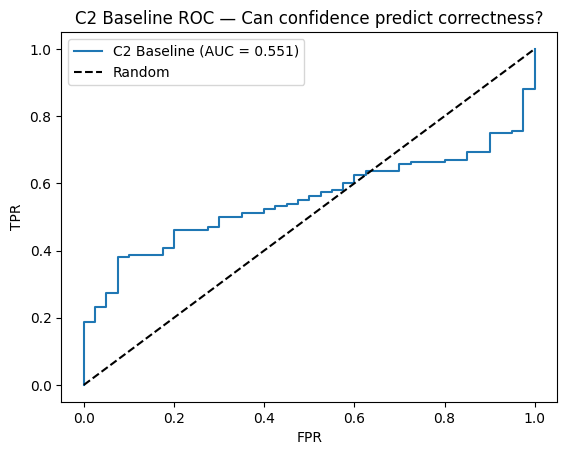

In [17]:
# ── ROC Curve ──────────────────────────────────────────────────────

fpr, tpr, _ = roc_curve(y_valid, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"C2 Baseline (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("C2 Baseline ROC — Can confidence predict correctness?")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "c2_baseline_roc.png"), dpi=150)
plt.show()

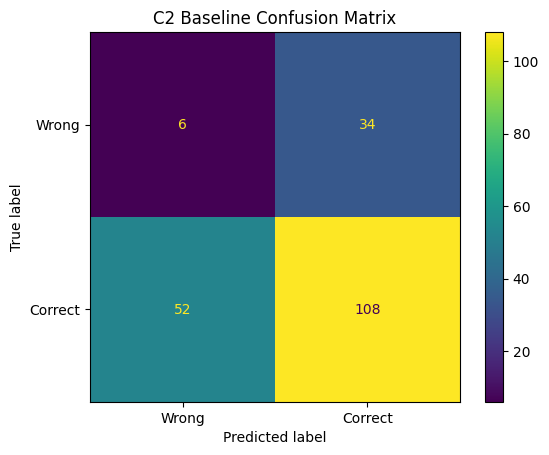

In [18]:
# ── Confusion Matrix ───────────────────────────────────────────────

cm = confusion_matrix(y_valid, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Wrong", "Correct"]).plot()
plt.title("C2 Baseline Confusion Matrix")
plt.savefig(os.path.join(OUTPUT_DIR, "c2_baseline_cm.png"), dpi=150)
plt.show()

In [20]:
# ── Save model and scaler ──────────────────────────────────────────
# You'll need these later to compare against the counterfactual C2

joblib.dump(c2,     os.path.join(OUTPUT_DIR, "c2_baseline.pkl"))
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "c2_baseline_scaler.pkl"))
print("Saved C2 baseline model and scaler.")

Saved C2 baseline model and scaler.
